In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import *

In [147]:
# Read in files containing oligo pools used to assemble CRE-barcode cassettes
enhlibV4 = pd.read_excel(r'C:\Users\zgibbs\Documents\Oligo pools\enhlibV4.xlsx')
barlibV4 = pd.read_excel(r'C:\Users\zgibbs\Documents\Oligo pools\barlibV4.xlsx')

enhlibV4 = pd.read_excel(r'C:\Users\zgibbs\Documents\Oligo pools\enhlibV4.xlsx')
barlibV4 = pd.read_excel(r'C:\Users\zgibbs\Documents\Oligo pools\barlibV4.xlsx')

enhlibV6 = pd.read_excel(r'C:\Users\zgibbs\Documents\Oligo pools\enhlibV6.xlsx')
barlibV6 = pd.read_excel(r'C:\Users\zgibbs\Documents\Oligo pools\barlibV6.xlsx')

enhlibV8 = pd.read_excel(r'C:\Users\zgibbs\Documents\Oligo pools\enhlibV8.xlsx')
barlibV8 = pd.read_excel(r'C:\Users\zgibbs\Documents\Oligo pools\barlibV8.xlsx')

In [150]:
enhlibV8["Sequence (5'-3')"][:40]

0     CATGGACGAGCTGTACAAGTAAGttaatctcagctagcctaactct...
1     CATGGACGAGCTGTACAAGTAAGtggctttcacggccgttcccctc...
2     CATGGACGAGCTGTACAAGTAAGgcttgcctaatgaaaaataaatg...
3     CATGGACGAGCTGTACAAGTAAGtttctgaacaccccactgatacc...
4     CATGGACGAGCTGTACAAGTAAGttcctttcaaggacatcttggca...
5     CATGGACGAGCTGTACAAGTAAGctttgatatcatcccaaagaagt...
6     CATGGACGAGCTGTACAAGTAAGgtgttatctaagtgatgcctttt...
7     CATGGACGAGCTGTACAAGTAAGaacttccctctggtgtcttagtg...
8     CATGGACGAGCTGTACAAGTAAGtccacatgatgtctgaaatgaga...
9     CATGGACGAGCTGTACAAGTAAGaacatcaacttacacaaccgtca...
10    CATGGACGAGCTGTACAAGTAAGtttaaatatgaaaggagaataac...
11    CATGGACGAGCTGTACAAGTAAGtatattttcactaaaaggggaaa...
12    CATGGACGAGCTGTACAAGTAAGtttcttacctttctttctgtgta...
13    CATGGACGAGCTGTACAAGTAAGgtttttaaaggatttcatgcatt...
14    CATGGACGAGCTGTACAAGTAAGaatagaggtctctttaaagacct...
15    CATGGACGAGCTGTACAAGTAAGagttttgtcctctgaatgatcca...
16    CATGGACGAGCTGTACAAGTAAGtcttaactccacagaggaccgat...
17    CATGGACGAGCTGTACAAGTAAGaattcctgcatctcttctt

In [40]:
nts = ['C', 'A', 'T', 'G', 'AT', 'AC', 'AG', 'AA', 'CA', 'CC', 'CG', 'CT', 'GT', 'GA', 'GG', 'GC', 'TT', 'TA', 'TC', 'TG']

In [41]:
enh_stats = enhlibV8.copy()
enh_cols = []
for nt in nts:
    col = f'overlap_{nt}'
    enh_cols.append(col)
    enh_stats[f'overlap_{nt}'] = enh_stats["Sequence (5'-3')"].apply(lambda x : x.upper()[-40:].count(nt))
    
    col = f'enh_{nt}'
    enh_cols.append(col)
    enh_stats[f'enh_{nt}'] = enh_stats["Sequence (5'-3')"].apply(lambda x : x.upper()[20:-40].count(nt))

    # model coefficients for enh barcode region, and enhancer region are the same
    # col = f'enh_{nt}'
    # enh_cols.append(col)
    # enh_stats[f'enh_{nt}'] = enh_stats["Sequence (5'-3')"].apply(lambda x : x.upper()[20:-120].count(nt))

In [42]:
bar_stats = barlibV8.copy()
bar_cols = []
for nt in nts:
    col = f'bar_overlap_{nt}'
    bar_cols.append(col)
    bar_stats[f'bar_overlap_{nt}'] = bar_stats["Sequence (5'-3')"].apply(lambda x : x.upper()[-40:].count(nt))
    col = f'barcode_{nt}'
    bar_cols.append(col)
    bar_stats[f'barcode_{nt}'] = bar_stats["Sequence (5'-3')"].apply(lambda x : x.upper()[20:-40].count(nt))

In [43]:
cts_seq =  {int(ln.split('CRE')[-1]):int(ln.split('CRE')[0]) for ln in open(r'C:\Users\zgibbs\cellpose\bulk_sequencing\plasmidsaurus_20250213\N5LC7G_4_sample_4_counts','r')}
cts_seq = np.array([cts_seq.get(i+1,0)for i in np.arange(400)])

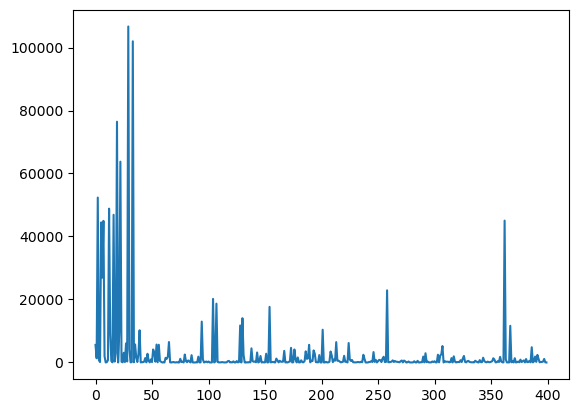

In [184]:
plt.plot(cts_seq)

In [44]:
enh_stats['plasmid_counts']= cts_seq

In [45]:
len(enh_stats.columns)

44

In [46]:
enh_stats['pool'] = pd.Series(enh_stats.index.values).apply(lambda x : x//40)

In [47]:
pool_sum = enh_stats.groupby('pool')['plasmid_counts'].sum()

In [48]:
enh_stats['norm_counts'] = np.log((enh_stats['plasmid_counts'] * 5e5)/enh_stats['pool'].map(pool_sum) + 1)

In [49]:
model_stats = enh_stats.join(bar_stats, rsuffix='_bar')

In [50]:
from scipy.stats import spearmanr, pearsonr

In [51]:
test_pools = (2, 7)

In [137]:
from scipy.stats import zscore

In [52]:
train_use = model_stats.copy()


In [64]:
barcode_nt = [f'barcode_{i}' for i in nts]
enh_nt = [f'enh_{i}' for i in nts]
enh_olap_nt = [f'overlap_{i}' for i in nts]

bc_overlap_nt = [f'bar_overlap_{i}' for i in nts]

In [138]:
# x_cols = enh_nt + barcode_nt + bc_overlap_nt +
# x_cols = bc_overlap_nt + barcode_nt
x_cols= barcode_nt + bc_overlap_nt + enh_nt
# enh_nt
train_use[x_cols] = train_use[x_cols].apply(zscore)


In [139]:
from sklearn.linear_model import LassoCV, Lasso

In [140]:
enhancer_sequence_model = LassoCV(max_iter=2000, cv=10)

In [141]:
enhancer_sequence_model = enhancer_sequence_model.fit(train_use[x_cols], train_use['norm_counts'])

In [142]:
enhancer_sequence_model.score(train_use[x_cols], train_use['norm_counts'])

0.12331776054529153

In [143]:
enhancer_sequence_model.alpha_

0.10593246612405675

In [144]:
np.array(x_cols)[enhancer_sequence_model.coef_>0]

array(['barcode_C', 'barcode_AC', 'barcode_CA', 'barcode_TT',
       'bar_overlap_C', 'bar_overlap_GG', 'enh_AC', 'enh_CA', 'enh_CT'],
      dtype='<U14')

In [145]:
coefs = pd.Series(index = np.array(x_cols)[np.abs(enhancer_sequence_model.coef_)>0], data=enhancer_sequence_model.coef_[np.abs(enhancer_sequence_model.coef_)>0])

In [146]:
coefs.sort_values()

bar_overlap_T    -0.275722
bar_overlap_A    -0.233137
bar_overlap_TA   -0.084945
enh_TA           -0.071314
enh_CG           -0.061390
enh_AT           -0.034468
enh_GG           -0.024071
bar_overlap_AG   -0.011261
bar_overlap_TT   -0.006063
barcode_TT        0.014531
barcode_CA        0.020469
barcode_AC        0.033987
enh_AC            0.036471
bar_overlap_GG    0.039254
enh_CA            0.063394
barcode_C         0.218614
enh_CT            0.249904
bar_overlap_C     0.262354
dtype: float64

In [60]:
# enhancer_sequence_model.score(enh_stats.loc[enh_stats.pool.isin(test_pools), enh_cols], enh_stats.loc[enh_stats.pool.isin(test_pools), 'norm_counts'])

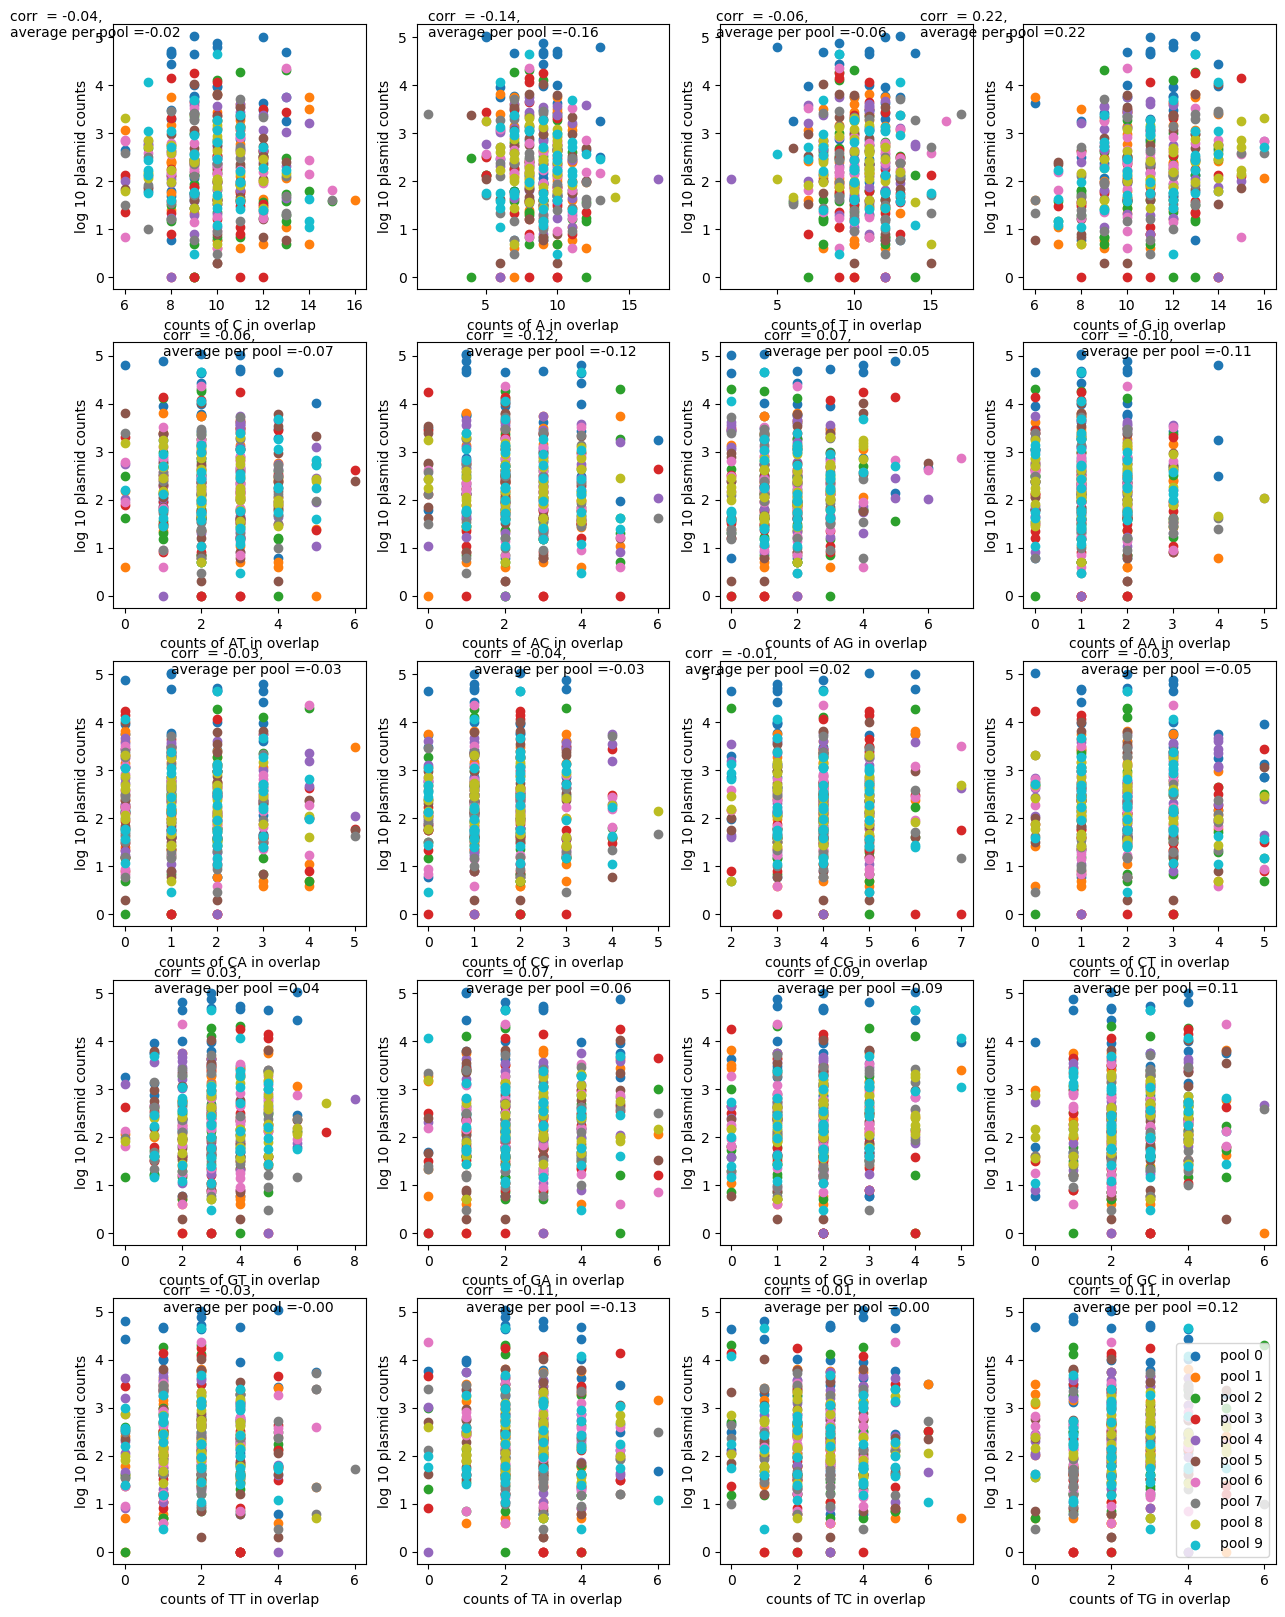

In [61]:
fig, axs = plt.subplots(5, 4, figsize=(15, 20))
axs = axs.flatten()
count = 0
region = 'overlap'
for nt, ax in zip(nts, axs):
    r_all = spearmanr(enh_stats[f'{region}_{nt}'], enh_stats['plasmid_counts'].apply(lambda x : np.log10(x+1)))[0]
    rs =[]
    for pool in enh_stats.pool.unique():
        rs.append(spearmanr(
                    enh_stats.loc[enh_stats.pool == pool, f'{region}_{nt}'],
                       enh_stats.loc[enh_stats.pool == pool, 'plasmid_counts'].apply(lambda x : np.log10(x+1)))[0])
        ax.scatter(enh_stats.loc[enh_stats.pool == pool, f'{region}_{nt}'],
                   enh_stats.loc[enh_stats.pool == pool, 'plasmid_counts'].apply(lambda x : np.log10(x+1)),
                   label=f'pool {pool}')
    ax.text(1, 5,
            f'corr  = {r_all:.2f}, \naverage per pool ={np.mean(rs):.2f}')
    if count % 4 == 0:
        ax.set_ylabel('log 10 plasmid counts')
    ax.set_xlabel(f'counts of {nt} in {region}')
ax.legend()

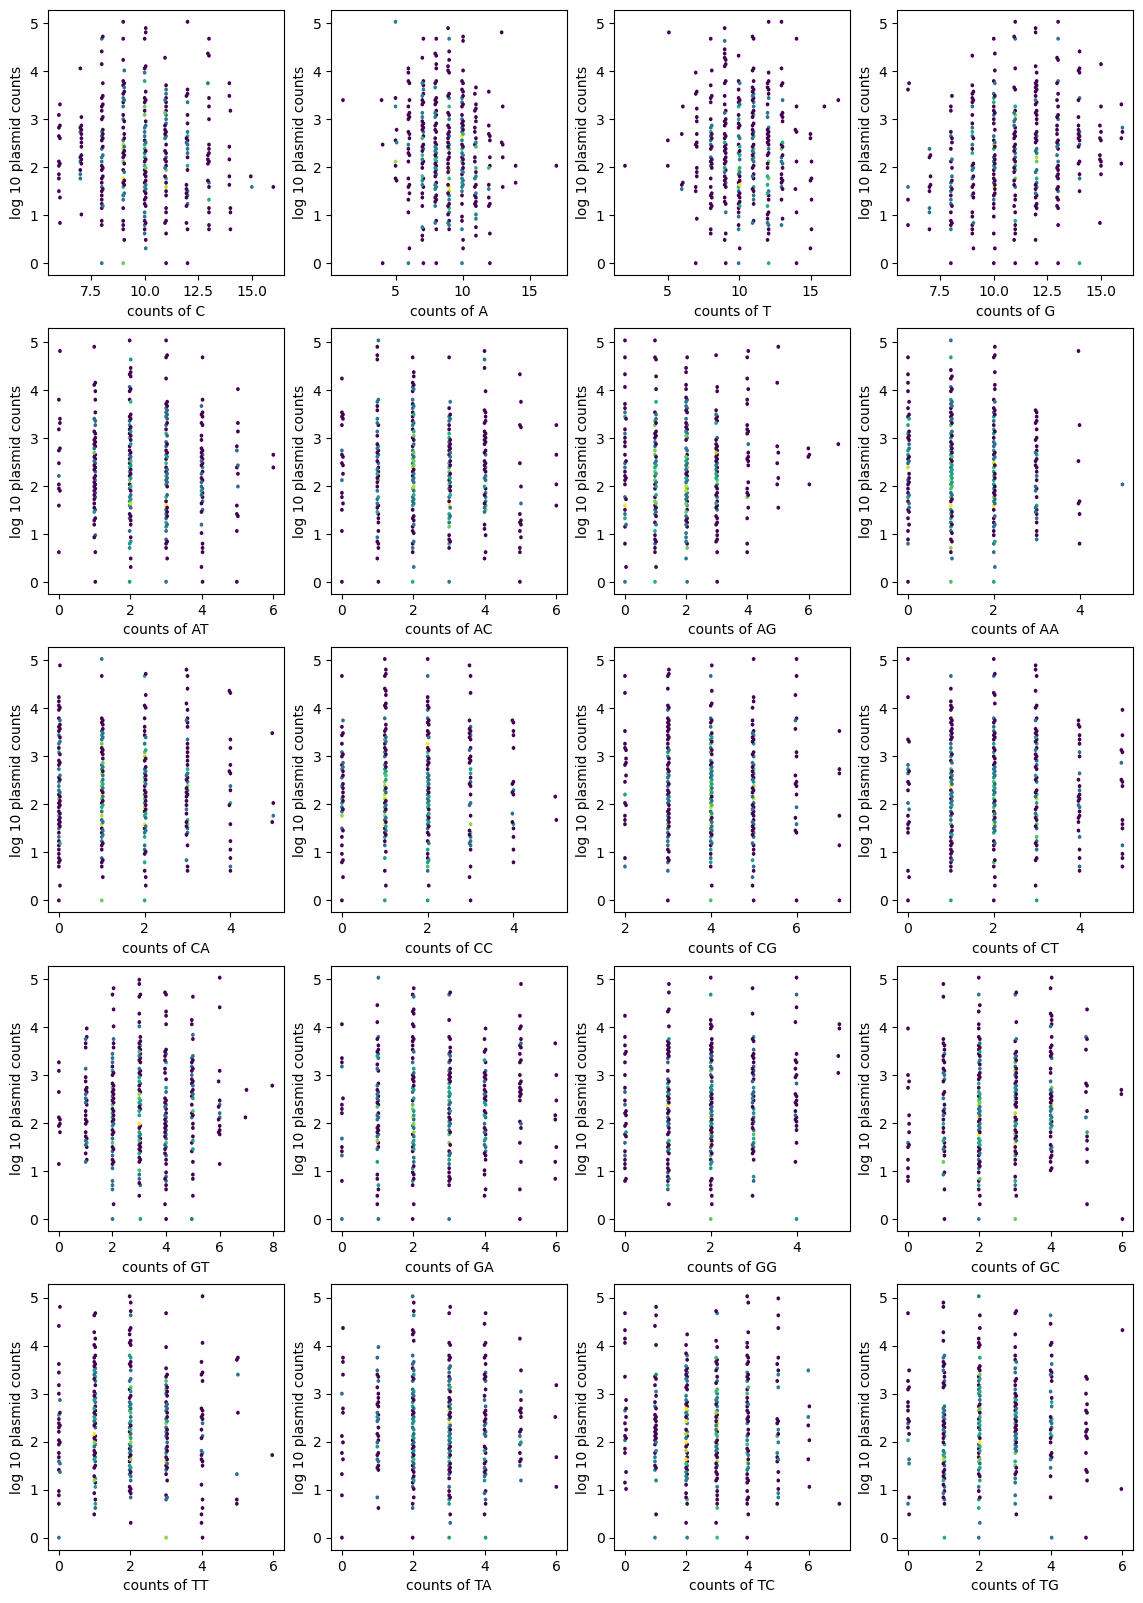

In [62]:
fig, axs = plt.subplots(5, 4, figsize=(14, 20))
axs = axs.flatten()
count = 0
for nt, ax in zip(nts, axs):
    ax.hexbin(enh_stats[f'overlap_{nt}'], enh_stats['plasmid_counts'].apply(lambda x : np.log10(x+1)), bins='log')
    if count % 4 == 0:
        ax.set_ylabel('log 10 plasmid counts')
    ax.set_xlabel(f'counts of {nt}')

### Generate a list containing the enhancer-barcode fragments

In [102]:
# Generate lists for both enhancer fragments and barcode fragments (reverse complemented)
from Bio.Seq import Seq

enhlib = []
barlibRC = []

for i in range(400):
    enh_seq = Seq(enhlibV8["Sequence (5'-3')"][i])
    enhlib.append(str(enh_seq))
    
for i in range(400): 
    bc_seq = Seq(barlibV8["Sequence (5'-3')"][i])
    barlibRC.append(str(bc_seq.reverse_complement()))

In [108]:
# Combine the enhancer and barcode fragments, trimming off all primer sequences and the homologous region from the barcode fragment
SFv8_seq = []

for i in range(400):
    fl_seq = enhlib[i][23:] + barlibRC[i][40:-31] # may need to change ranges depending on primer/overlap size
    SFv8_seq.append(fl_seq)

In [110]:
len(SFv8_seq[0])

570

### Generate fasta file for the enhancer-barcode fragments

In [62]:
from functions_by_ethan import * 
# read_list, write_list, write_fasta

In [111]:
# Create list of enhancer names
names = [f'CRE{str(i).zfill(3)}' for i in range(1, 401)]

# assign the enhancer-barcode seqs to new variable
seqs = SFv8_seq

# create dictionary reference for CRE-barcode names and seqs
dict_ref = {name : seq for name, seq in zip(names, seqs)}

# write the new fasta file
write_fasta('400_CRE.fasta', dict_ref)

231600

### Generate gff annotation file for reference

In [73]:
from BCBio import GFF
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.SeqFeature import SeqFeature, FeatureLocation

out_file = "20CRE.gff"
seq = Seq(SFv4_seq[0])
rec = SeqRecord(seq, "CRE001")
qualifiers = {
    "source": "SFv4",
    "score": 10.0,
    "other": ["Some", "annotations"],
    "ID": "gene1",
}
sub_qualifiers = {"source": "prediction"}
top_feature = SeqFeature(
    FeatureLocation(0, 572), type="gene", strand=1, qualifiers=qualifiers
)
top_feature.sub_features = [
    SeqFeature(FeatureLocation(1, 190), type="exon", strand=1, qualifiers=sub_qualifiers),
    SeqFeature(
        FeatureLocation(191, 573), type="exon", strand=1, qualifiers=sub_qualifiers
    ),
]
rec.features = [top_feature]

with open(out_file, "w") as out_handle:
    GFF.write([rec], out_handle)

In [72]:
import gffutils

##### *Swap AB positive control enhancers in to sublib 1 & 2*

In [151]:
from Bio.Seq import Seq

enhlib = []

for i in range(40):
    enh_seq = Seq(enhlibV8["Sequence (5'-3')"][i])
    enhlib.append(str(enh_seq))

In [178]:
SFv8_01 = []

for i in range(40):
    fl_seq = enhlib[i][:23] + pos_ctrl_seqs[i] + enhlib[i][213:] # may need to change ranges depending on primer/overlap size
    SFv8_01.append(fl_seq)

In [179]:
SFv8_01

['CATGGACGAGCTGTACAAGTAAGaaagctggaggggacaaaggatgctcaccttagaccaaggaagcagagccaagaagcacacatgcttgctgtgtaccataaatgcaatttttggaatgatgacaacagaaaagatgcaattcttagcatagactcagtcctgccaagagctgtctgacaatgtaggaaggattatttcaggaggaaaacaGCCACCTTAACACGCGATGAGGGTACATGCGCCTTACTCCGGATACATATACGCTCGTCGAGGGCCAAGTCGACCTAGATgcaatttgcgcttgttcggctaacgattttctcgcgggag',
 'CATGGACGAGCTGTACAAGTAAGtcagaccacccaagcaaacaccagggctgcttttctctgagcattctgccagattacagcagagcgggctgggtcccgggagggggtgtggaagggggtgctggcgctgaacagaggaaggctttcagagcctggacttgccaagtctcacagtctcgctttcacacattgcttctcaatcttggtgctgCCAATTAGGGCCGTTGTCACTAGCGATTATGTTCCCGTTTTATTCGAGGATGGATTCGGGTTGGGCCGATAAGTTGAGTAgcattctggttcgcagctatacttctccgaactagcggga',
 'CATGGACGAGCTGTACAAGTAAGgttgcccaggatatacttgaacttgaaggttcctcagctgagtcttcttctccagcctccagttacctgagcctgcaggatgtgtctcgggatgcagatattttgggaagagagagactcagtgccagacagatttcacaagtgtacatacacctcagaaaagaaaaaaactttacttcccaggaatagtTCGTATGGGCGGTTCACTTACGACGGGCAACTATTCGAGTGTTGTGACATCGTGGGGACGGTCGTCTAAGGGGCCTACTCgaagcgatcgtgctagtagtcatggcatt

In [163]:
enhlib[0][213:]

'GCCACCTTAACACGCGATGAGGGTACATGCGCCTTACTCCGGATACATATACGCTCGTCGAGGGCCAAGTCGACCTAGATgcaatttgcgcttgttcggctaacgattttctcgcgggag'

In [182]:
bed_file = pd.read_table(r'C:\Users\zgibbs\Allen_Brain_hall_of_fame_controls\final_pos_ctrls.bed', header=True)

TypeError: Passing a bool to header is invalid. Use header=None for no header or header=int or list-like of ints to specify the row(s) making up the column names

In [183]:
bed_file

,chr12,63319677,63319867,AiE0680m_1
0,chr9,57566008,57566198,AiE2586m_1
1,chr9,56037526,56037716,AiE2356m_1
2,chr9,56037108,56037298,AiE2356m_2
3,chr10,75411507,75411697,AiE0784m_1
4,chr10,19829367,19829557,AiE0779m_6xC2_1
5,chr3,135176767,135176957,AiE0743m_3xC2_1
6,chr16,88302565,88302755,AiE0050m_3xC2_1
7,chr1,193298474,193298664,AiE2016m_1
8,chr1,193298203,193298393,AiE2016m_2
9,chr4,119044349,119044539,AiE2135m_1


In [176]:
pos_ctrls = r'C:\Users\zgibbs\Allen_Brain_hall_of_fame_controls\final_pos_ctrls.fa'

pos_ctrl_seqs = []
for record in SeqIO.parse(pos_ctrls, "fasta"):
    pos_ctrl_seqs.append(str(record.seq.lower()))


In [177]:
pos_ctrl_seqs

['aaagctggaggggacaaaggatgctcaccttagaccaaggaagcagagccaagaagcacacatgcttgctgtgtaccataaatgcaatttttggaatgatgacaacagaaaagatgcaattcttagcatagactcagtcctgccaagagctgtctgacaatgtaggaaggattatttcaggaggaaaaca',
 'tcagaccacccaagcaaacaccagggctgcttttctctgagcattctgccagattacagcagagcgggctgggtcccgggagggggtgtggaagggggtgctggcgctgaacagaggaaggctttcagagcctggacttgccaagtctcacagtctcgctttcacacattgcttctcaatcttggtgctg',
 'gttgcccaggatatacttgaacttgaaggttcctcagctgagtcttcttctccagcctccagttacctgagcctgcaggatgtgtctcgggatgcagatattttgggaagagagagactcagtgccagacagatttcacaagtgtacatacacctcagaaaagaaaaaaactttacttcccaggaatagt',
 'gaaagacttgaaccttccatggtccagaaatctcagcatgactagaaagtgtattcctcactgggagtagtgcgtgctgcagataggtttttaagtggagttatatagtggcagagatagggagcggatgcttgggcttgattccagagtatctgtaatgtttctcttttctaaatagtctttatttttg',
 'tcacccagaaagaggaactagaaccacaagagcctaaccccccacggtgggaagacactctgtggcatcaccgggaggggaggccaggtgtgggcaactgcagctatttctaatccaccagaggaaagagagctttgactgcttgaaaagcaggctgattgtcaggggcggaacccagctcagagctgtc',
 'gtttgagacaaattaaggaaaag

In [166]:
from Bio import SeqIO

pos_ctrls = r'C:\Users\zgibbs\Allen_Brain_hall_of_fame_controls\final_pos_ctrls.fa'
for record in SeqIO.parse(pos_ctrls, "fasta"):
    # Each record contains a sequence and its metadata
    print(f"ID: {record.id}")        # The identifier (header) of the sequence
    print(f"Sequence: {record.seq}")  # The sequence itself

ID: chr12:63319677-63319867
Sequence: AAAGCTGGAGGGGACAAAGGATGCTCACCTTAGACCAAGGAAGCAGAGCCAAGAAGCACACATGCTTGCTGTGTACCATAAATGCAATTTTTGGAATGATGACAACAGAAAAGATGCAATTCTTAGCATAGACTCAGTCCTGCCAAGAGCTGTCTGACAATGTAGGAAGGATTATTTCAGGAGGAAAACA
ID: chr9:57566008-57566198
Sequence: TCAGACCACCCAAGCAAACACCAGGGCTGCTTTTCTCTGAGCATTCTGCCAGATTACAGCAGAGCGGGCTGGGTCCCGGGAGGGGGTGTGGAAGGGGGTGCTGGCGCTGAACAGAGGAAGGCTTTCAGAGCCTGGACTTGCCAAGTCTCACAGTCTCGCTTTCACACATTGCTTCTCAATCTTGGTGCTG
ID: chr9:56037526-56037716
Sequence: gttgcccaggatatacttgaacttgaaggttcctcagctgagtcttcttctccagcctccagttacctgagcctgcaggatgtgtcTCGGGATGCAGATATTTTGGGAAGAGAGAGACTCAGTGCCAGACAGATTTCACAAGTGTACATACACCTCAGAAAAGAAAAAAACTTTACTTCccaggaatagt
ID: chr9:56037108-56037298
Sequence: GAAAGACTTGAACCTTCCATGGTCCAGAAATCTCAGCATGACTAGAAAGTGTATTCCTCACTGGGAGTAGTGCGTGCTGCAGATAGGTTTTTAAGTGGAGTTATATAGTGGCAGAGATAGGGAGCGGATGCTTGGGCTTGATTCCAGAGTATCTGTAATGTTTCTCTTTTCTAAATAGTCTTTAtttttg
ID: chr10:75411507-75411697
Sequence: TCACCCAGAAAGAGGAACTAGAACCACAAGAGCCTAACCCCCCACGGTG